In [25]:
import sys
# Add parent directory to path to import from src/
sys.path.append(str(Path(__file__).parent.parent) if '__file__' in globals() else str(Path.cwd().parent))

from sionna.rt import load_scene, RadioMapSolver, Camera, transform_mesh, MeshRadioMap, PlanarRadioMap
from pathlib import Path
from src.utils import load_building_positions, get_antenna_positions, get_scene_bounds
from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array

In [31]:
# Define parameters
NUM_DEPLOYMENT_BUILDINGS = 3
ANTENNA_HEIGHT_OFFSET = 10.0
SHIFT_FACTOR = 0.25
SCENE_CENTER = [0.0, 0.0]
ELEVATION = True
scene_dir = Path("../scenes/boston_downtown_lidar/")
scene_xml_path = scene_dir / "scene.xml"
building_positions_path = scene_dir / "buildings.json"

In [32]:
# setup scene and measurement surface
scene = load_scene(scene_xml_path)
bbox_min, bbox_max = get_scene_bounds(scene)

if ELEVATION:
    measurement_surface = scene.objects["ground"].clone(as_mesh=True)
    transform_mesh(measurement_surface,
                translation=[0,0,1.5])
else:
    measurement_surface = None

building_positions = load_building_positions(building_positions_path)

antenna_information = get_antenna_positions(
    building_positions, 
    scene_center=SCENE_CENTER,
    antenna_height_offset=ANTENNA_HEIGHT_OFFSET,
    shift_factor=SHIFT_FACTOR,
    num_deployment_buildings=NUM_DEPLOYMENT_BUILDINGS)

2026-01-05 13:33:18 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


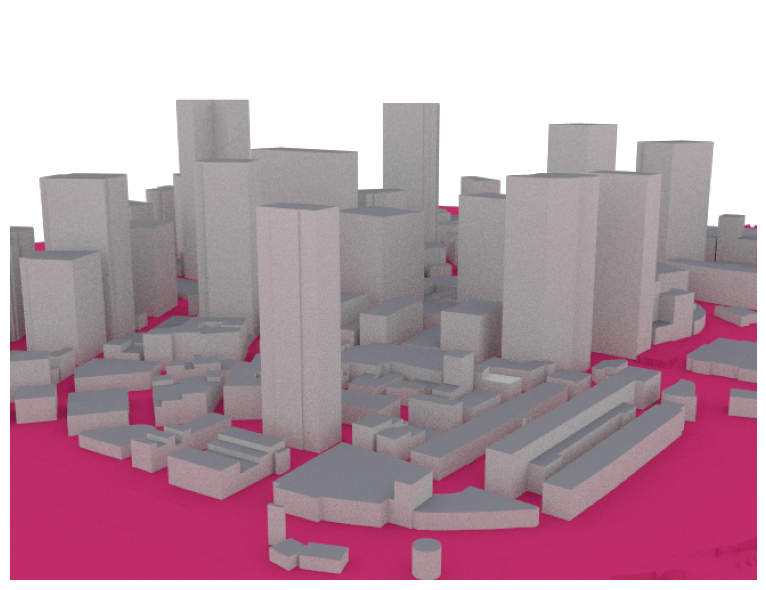

In [33]:
# Position camera at a good viewing distance from the scene center at look at the scene center
camera = Camera(position=bbox_max, look_at=[0, 0, 0])
scene.render(camera=camera);

In [34]:
# set tx and rx specs and add base stations
set_tx_antenna_array(
    scene,
    num_rows=8,
    num_cols=8,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",
    polarization="cross")

set_rx_antenna_array(
    scene,
    num_rows=2,
    num_cols=2,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="hw_dipole",
    polarization="VH"
)

for i, current_antenna_information in enumerate(antenna_information):
    bs_name = f"BS_{i}"
    _, antenna_position = current_antenna_information
    print(f"Adding base station {bs_name} at position {antenna_position}")
    add_base_station(
        scene,
        bs_name,
        position=antenna_position,
        num_sectors=6,
        mechanical_tilt=10.0,
        azimuth_offset=0.0,
        tx_power_dbm=43.0,
        display_radius=15.0
    )

Antenna Array Configuration Set:
  - Array: 8x8 (128 elements)
  - Pattern: tr38901, Polarization: cross
  - Spacing: V=0.5λ, H=0.5λ
  - Estimated beamwidth: [15.3]°
UE Antenna Array Configuration Set:
  - Array: 2x2 (8 elements)
  - Pattern: hw_dipole, Polarization: VH
  - Spacing: V=0.5λ, H=0.5λ
Adding base station BS_0 at position [36.266853801181206, -215.54864270491936, 218.5]
Added BS_0_sector_1 at position [[36.2669, -215.549, 218.5]], azimuth 0.0°
Added BS_0_sector_2 at position [[36.2669, -215.549, 218.5]], azimuth 60.0°
Added BS_0_sector_3 at position [[36.2669, -215.549, 218.5]], azimuth 120.0°
Added BS_0_sector_4 at position [[36.2669, -215.549, 218.5]], azimuth 180.0°
Added BS_0_sector_5 at position [[36.2669, -215.549, 218.5]], azimuth 240.0°
Added BS_0_sector_6 at position [[36.2669, -215.549, 218.5]], azimuth 300.0°

Base Station 'BS_0' Summary:
  - Sectors: 6
  - Mechanical tilt: 10.0°
  - TX Power: 43.0 dBm
  - Position: [[36.2669], [-215.549], [218.5]] m
Adding base 

In [35]:
scene.preview();

In [ ]:
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               measurement_surface=measurement_surface,
               diffuse_reflection=True,
               diffraction=True,
               edge_diffraction=True,
               max_depth=5,           # Maximum number of ray scene interactions
               samples_per_tx=10**6) # If you increase: less noise, but more memory required

In [ ]:
scene.objects

In [ ]:
if isinstance(rm, MeshRadioMap):
    scene.preview(radio_map=rm, rm_db_scale=True, rm_metric="path_gain");

In [ ]:
if isinstance(rm, PlanarRadioMap):
    rm.show(metric="path_gain", tx=0);